> **Superseded exploratory notebook** — groundwork for secondary early data analysis (publication month, author history). Not part of the final modelling pipeline; see `EDA/book_success_merge.ipynb` and `methodology/design.md` for the canonical pipeline.

- Books published each month `pub_month`
- Author prior success `max_author_prior_nyt_count`: for each book, count how many NYT bestsellers each author had strictly before the book's publication year, then take the maximum across authors.

## 1. EDA for Publishing month



In [ ]:
import sys
from pathlib import Path
import pandas as pd
import os
import json
import importlib.util

# Make paths robust whether the notebook kernel starts in project root or notebooks/.
NOTEBOOK_CWD = Path.cwd().resolve()
if (NOTEBOOK_CWD / "data" / "merged_books_fiction_only.csv").exists():
    PROJECT_ROOT = NOTEBOOK_CWD
else:
    PROJECT_ROOT = NOTEBOOK_CWD.parent

# Load data
DATA_PATH = PROJECT_ROOT / "data" / "merged_books.csv"
df = pd.read_csv(DATA_PATH, dtype={"isbn13": str})

print(df.shape)
display(df.head())

(7983, 46)


,authors,average_rating,best_book_id,book_id,books_count,description,genres,goodreads_book_id,image_url,isbn,...,nyt_author,nyt_title_norm,nyt_author_norm,nyt_bestseller,weeks_on_list,best_rank_achieved,nyt_first_year,debut_rank,match_method,is_nyt_match
0,['Suzanne Collins'],4.34,2767052,1,272,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"['young-adult', 'fiction', 'fantasy', 'science...",2767052,https://images.gr-assets.com/books/1447303603m...,439023483,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,unmatched,0
1,"['J.K. Rowling', 'Mary GrandPré']",4.44,3,2,491,Harry Potter's life is miserable. His parents ...,"['fantasy', 'fiction', 'young-adult', 'classics']",3,https://images.gr-assets.com/books/1474154022m...,439554934,...,J. K. Rowling,NaN,NaN,1,82,1.0,1998.0,16.0,fuzzy_title_author,1
2,['Stephenie Meyer'],3.57,41865,3,226,About three things I was absolutely positive.\...,"['young-adult', 'fantasy', 'romance', 'fiction...",41865,https://images.gr-assets.com/books/1361039443m...,316015849,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,unmatched,0
3,['Harper Lee'],4.25,2657,4,487,The unforgettable novel of a childhood in a sl...,"['classics', 'fiction', 'historical-fiction', ...",2657,https://images.gr-assets.com/books/1361975680m...,61120081,...,Harper Lee,NaN,NaN,1,98,2.0,1960.0,13.0,fuzzy_title_author,1
4,['John Green'],4.26,11870085,6,226,Despite the tumor-shrinking medical miracle th...,"['young-adult', 'romance', 'fiction', 'contemp...",11870085,https://images.gr-assets.com/books/1360206420m...,525478817,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,unmatched,0


In [ ]:
def pub_month_feature(
    df: pd.DataFrame,
    date_col: str = "publishdate",
    one_hot: bool = True
) -> pd.DataFrame:
    """
    Create publication-month features from mixed publishdate formats.

    Handles:
        - 09/14/08
        - September 6th 2006
        - November 2002
        - August 7th 2007
        - ('6', '1', '2006')

    If only year is available, e.g. (None, None, '2003'),
    month is treated as missing.
    """
    import ast
    import re

    out = pd.DataFrame(index=df.index)

    def extract_month(x):
        if pd.isna(x):
            return None

        # Handle actual tuple/list values
        if isinstance(x, (tuple, list)):
            if len(x) >= 1 and x[0] not in [None, "None", "nan", ""]:
                try:
                    m = int(x[0])
                    if 1 <= m <= 12:
                        return m
                except Exception:
                    pass
            return None

        s = str(x).strip()

        if s.lower() in ["nan", "none", ""]:
            return None

        # Handle tuple-like strings, e.g. "('6', '1', '2006')"
        if s.startswith("(") and s.endswith(")"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (tuple, list)):
                    if len(parsed) >= 1 and parsed[0] not in [None, "None", "nan", ""]:
                        m = int(parsed[0])
                        if 1 <= m <= 12:
                            return m
                return None
            except Exception:
                return None

        # Remove ordinal suffixes: 1st, 2nd, 3rd, 4th -> 1, 2, 3, 4
        s = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", s)

        # Try flexible datetime parsing
        dt = pd.to_datetime(s, errors="coerce", format="mixed")

        if pd.isna(dt):
            return None

        return dt.month

    out["pub_month"] = df[date_col].apply(extract_month)
    out["pub_month_missing"] = out["pub_month"].isna().astype(int)

    out["pub_month"] = out["pub_month"].fillna(0).astype(int)

    if one_hot:
        for m in range(1, 13):
            out[f"pub_month_{m}"] = (out["pub_month"] == m).astype(int)

    return out


In [ ]:
pm = pub_month_feature(df, date_col="publishdate")

display(pm.head())
display(pm.describe())
print("Missing month rate:", pm["pub_month_missing"].mean())
display(pm["pub_month"].value_counts().sort_index())

,pub_month,pub_month_missing,pub_month_1,pub_month_2,pub_month_3,pub_month_4,pub_month_5,pub_month_6,pub_month_7,pub_month_8,pub_month_9,pub_month_10,pub_month_11,pub_month_12
0,9,0,0,0,0,0,0,0,0,0,1,0,0,0
1,11,0,0,0,0,0,0,0,0,0,0,0,1,0
2,9,0,0,0,0,0,0,0,0,0,1,0,0,0
3,5,0,0,0,0,0,1,0,0,0,0,0,0,0
4,1,0,1,0,0,0,0,0,0,0,0,0,0,0


,pub_month,pub_month_missing,pub_month_1,pub_month_2,pub_month_3,pub_month_4,pub_month_5,pub_month_6,pub_month_7,pub_month_8,pub_month_9,pub_month_10,pub_month_11,pub_month_12
count,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000,7983.000000
mean,6.096455,0.019917,0.110986,0.067644,0.075160,0.088563,0.094701,0.082801,0.067268,0.080045,0.100338,0.099712,0.065639,0.047225
std,3.452323,0.139725,0.314134,0.251149,0.263665,0.284130,0.292820,0.275598,0.250501,0.271380,0.300469,0.299634,0.247666,0.212134
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Missing month rate: 0.019917324314167605


pub_month
0     159
1     886
2     540
3     600
4     707
5     756
6     661
7     537
8     639
9     801
10    796
11    524
12    377
Name: count, dtype: int64

### Monthly distribution with NYT bestsellers highlighted

The bars show all books with a known publication month; the light-green portion at the bottom identifies NYT bestsellers.

Saved plot to: /Users/ronyang/Downloads/Erdos/Erdos2026-data-science/figures/books_by_publication_month.png


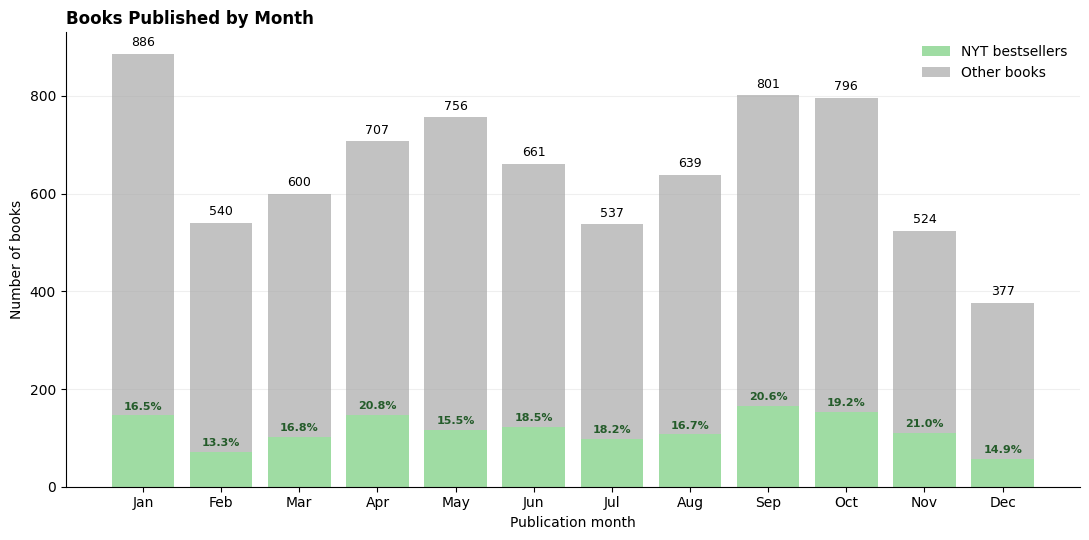

In [ ]:
import calendar
import matplotlib.pyplot as plt

monthly_plot = pd.DataFrame({
    "month": pm["pub_month"],
    "is_nyt": pd.to_numeric(df["nyt_bestseller"], errors="coerce").fillna(0).astype(bool),
})
monthly_plot = monthly_plot[monthly_plot["month"].between(1, 12)]

counts = (monthly_plot.groupby(["month", "is_nyt"]).size()
          .unstack(fill_value=0).reindex(range(1, 13), fill_value=0))
non_nyt = counts.get(False, pd.Series(0, index=counts.index))
nyt = counts.get(True, pd.Series(0, index=counts.index))
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")
ax.bar(month_labels, nyt, color="#8FD694", alpha=0.85, label="NYT bestsellers")
ax.bar(month_labels, non_nyt, bottom=nyt, color="#A9A9A9", alpha=0.70, label="Other books")

for x, (regular_count, nyt_count) in enumerate(zip(non_nyt, nyt)):
    total = regular_count + nyt_count
    ax.text(x, total + 10, f"{total:,}", ha="center", va="bottom", fontsize=9)
    if nyt_count:
        nyt_rate = nyt_count / total
        ax.text(x, nyt_count + 8, f"{nyt_rate:.1%}",
                ha="center", va="bottom", color="#245C2A", fontsize=8, fontweight="bold")

ax.set_title("Books Published by Month", loc="left", fontweight="bold")
ax.set_xlabel("Publication month")
ax.set_ylabel("Number of books")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()

# figure_dir = PROJECT_ROOT / "figures"
# figure_dir.mkdir(parents=True, exist_ok=True)
# figure_path = figure_dir / "books_by_publication_month.png"
# fig.savefig(figure_path, dpi=300, bbox_inches="tight", transparent=True)
# print(f"Saved plot to: {figure_path.resolve()}")

plt.show()

## 2. EDA for author

In [ ]:
def parse_authors(x):
    """
    Parse authors column into a Python list.
    Example:
        "['Suzanne Collins']" -> ['Suzanne Collins']
    """
    if isinstance(x, list):
        return x
    
    if pd.isna(x):
        return []
    
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return parsed
        return [str(parsed)]
    except Exception:
        return [str(x)]


def clean_author_name(x):
    """
    Normalize author names for grouping.
    """
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9\s]", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def max_author_prior_nyt_count(
    df: pd.DataFrame,
    author_col: str = "authors",
    year_col: str = "pub_year",
    target_col: str = "nyt_bestseller"
) -> pd.DataFrame:
    """
    Feature: max_author_prior_nyt_count

    For each book, count how many NYT bestsellers each author had strictly before
    the book's publication year, then take the maximum across authors.

    Important:
        This avoids leakage by using only books with pub_year < current pub_year.
        Same-year publications are excluded.
    """
    out = pd.DataFrame(index=df.index)
    out["max_author_prior_nyt_count"] = 0

    temp = df[[author_col, year_col, target_col]].copy()
    temp["_row_id"] = df.index

    temp[year_col] = pd.to_numeric(temp[year_col], errors="coerce")
    temp[target_col] = (
        pd.to_numeric(temp[target_col], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    rows = []

    for _, row in temp.iterrows():
        authors = parse_authors(row[author_col])

        for author in authors:
            author_clean = clean_author_name(author)

            if author_clean == "":
                continue

            rows.append({
                "_row_id": row["_row_id"],
                "author_clean": author_clean,
                "pub_year": row[year_col],
                "nyt_bestseller": row[target_col]
            })

    author_book = pd.DataFrame(rows)

    if author_book.empty:
        return out

    author_book = author_book.dropna(subset=["pub_year"])
    author_book["pub_year"] = author_book["pub_year"].astype(int)

    # One row per author-year.
    # This step is what prevents same-year leakage.
    author_year = (
        author_book
        .groupby(["author_clean", "pub_year"], as_index=False)
        .agg(
            year_nyt_count=("nyt_bestseller", "sum")
        )
        .sort_values(["author_clean", "pub_year"])
    )

    # For each author-year, prior NYT count = cumulative previous years only.
    author_year["author_prior_nyt_count"] = (
        author_year
        .groupby("author_clean")["year_nyt_count"]
        .cumsum()
        - author_year["year_nyt_count"]
    )

    # Attach author-year prior count back to each author-book row.
    author_book = author_book.merge(
        author_year[
            ["author_clean", "pub_year", "author_prior_nyt_count"]
        ],
        on=["author_clean", "pub_year"],
        how="left"
    )

    # For multi-author books, take the maximum prior NYT count.
    book_feature = (
        author_book
        .groupby("_row_id")["author_prior_nyt_count"]
        .max()
        .fillna(0)
        .astype(int)
    )

    out.loc[book_feature.index, "max_author_prior_nyt_count"] = book_feature

    return out


In [ ]:
import ast
import re

author_prior = max_author_prior_nyt_count(df)

display(author_prior.head())
display(author_prior.describe())
display(
    author_prior["max_author_prior_nyt_count"]
    .value_counts()
    .sort_index()
)

,max_author_prior_nyt_count
0,0
1,0
2,0
3,0
4,0


,max_author_prior_nyt_count
count,7983.000000
mean,1.144933
std,3.925122
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,42.000000


max_author_prior_nyt_count
0     6246
1      642
2      261
3      156
4      134
5       88
6       60
7       50
8       44
9       34
10      21
11      25
12      23
13      17
14      12
15       9
16      11
17       7
18      15
19      13
20       7
21      12
22      22
23       4
24       9
25      12
26       5
27       6
28       3
29       2
30       7
32       3
33       4
35       4
36       4
37       3
38       3
39       2
41       2
42       1
Name: count, dtype: int64

### Distribution of author prior NYT success

Books are grouped by the largest number of prior NYT bestsellers among their authors. Counts of five or more are combined for readability.

Saved plot to: /Users/ronyang/Downloads/Erdos/Erdos2026-data-science/figures/books_by_author_prior_nyt_success.png


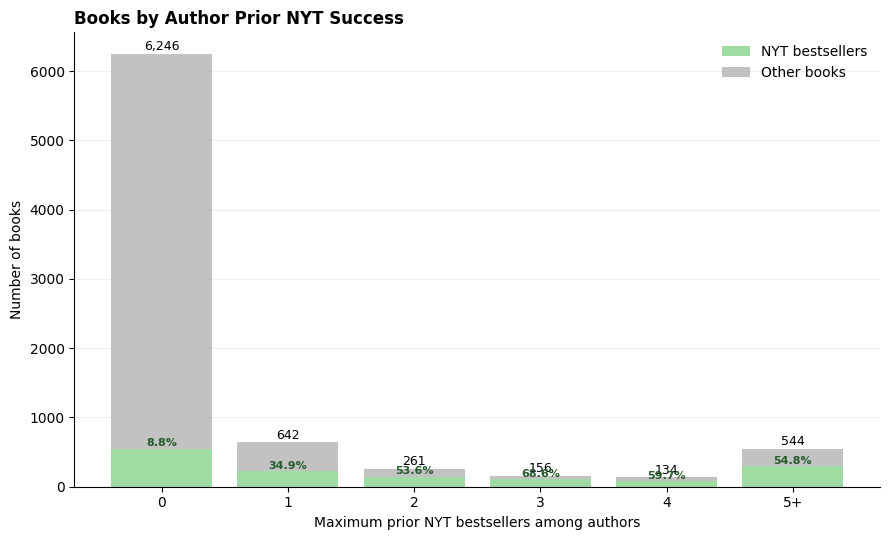

In [ ]:
author_plot = pd.DataFrame({
    "prior_nyt_count": author_prior["max_author_prior_nyt_count"],
    "is_nyt": pd.to_numeric(df["nyt_bestseller"], errors="coerce").fillna(0).astype(bool),
})

group_order = ["0", "1", "2", "3", "4", "5+"]
author_plot["prior_success_group"] = author_plot["prior_nyt_count"].clip(upper=5).astype(str)
author_plot.loc[author_plot["prior_nyt_count"] >= 5, "prior_success_group"] = "5+"

author_counts = (author_plot.groupby(["prior_success_group", "is_nyt"]).size()
                 .unstack(fill_value=0).reindex(group_order, fill_value=0))
author_non_nyt = author_counts.get(False, pd.Series(0, index=author_counts.index))
author_nyt = author_counts.get(True, pd.Series(0, index=author_counts.index))

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")
ax.bar(group_order, author_nyt, color="#8FD694", alpha=0.85, label="NYT bestsellers")
ax.bar(group_order, author_non_nyt, bottom=author_nyt, color="#A9A9A9", alpha=0.70, label="Other books")

for x, (regular_count, nyt_count) in enumerate(zip(author_non_nyt, author_nyt)):
    total = regular_count + nyt_count
    ax.text(x, total + 10, f"{total:,}", ha="center", va="bottom", fontsize=9)
    if total:
        nyt_rate = nyt_count / total
        ax.text(x, nyt_count + 8, f"{nyt_rate:.1%}",
                ha="center", va="bottom", color="#245C2A", fontsize=8, fontweight="bold")

ax.set_title("Books by Author Prior NYT Success", loc="left", fontweight="bold")
ax.set_xlabel("Maximum prior NYT bestsellers among authors")
ax.set_ylabel("Number of books")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()

figure_dir = PROJECT_ROOT / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "books_by_author_prior_nyt_success.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight", transparent=True)
print(f"Saved plot to: {figure_path.resolve()}")

plt.show()

## Key findings
- Publication month has a modest relationship with NYT success: monthly bestseller rates range from 13.3% to 21.0%.
- Author history is much stronger: books by authors with no prior NYT success have an 8.8% bestseller rate, compared with 34.9%–68.6% for authors with prior success.